# IEEE-CIS Fraud Detection - Decision Tree Experiment

## Setup

In [17]:
import os
import warnings
import pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

import mlflow
import mlflow.sklearn
import dagshub

print('All imports successful')

All imports successful


In [18]:
dagshub.init(
    repo_owner='sansi23',
    repo_name='IEEE-CIS-Fraud-Detection',
    mlflow=True
)

mlflow.set_experiment('DecisionTree_Training')

print(mlflow.get_tracking_uri())

Accessing as sansi23

Initialized MLflow to track repo "sansi23/IEEE-CIS-Fraud-Detection"

Repository sansi23/IEEE-CIS-Fraud-Detection initialized!

https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow


## Data Loading

In [19]:
train_transaction = pd.read_csv('train_transaction.csv')
train_identity    = pd.read_csv('train_identity.csv')
test_transaction  = pd.read_csv('test_transaction.csv')
test_identity     = pd.read_csv('test_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test  = test_transaction.merge(test_identity,  on='TransactionID', how='left')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()


Train shape: (590540, 434)
Test shape:  (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Fraud rate: 3.4990%


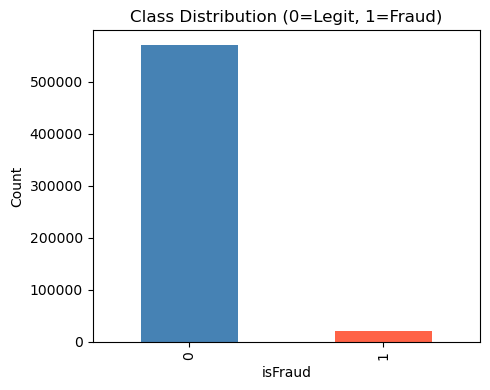

In [20]:
TARGET = 'isFraud'
ID_COL = 'TransactionID'

fraud_rate = train[TARGET].mean()
print(f'Fraud rate: {fraud_rate:.4%}')

fig, ax = plt.subplots(figsize=(5, 4))
train[TARGET].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution (0=Legit, 1=Fraud)')
ax.set_xlabel('isFraud')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [21]:
test_ids = test[ID_COL].copy()

X = train.drop(columns=[TARGET, ID_COL])
y = train[TARGET].astype(int)
X_test_raw = test.drop(columns=[ID_COL])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}')
print(f'Val size:   {X_val.shape}')

Train size: (472432, 432)
Val size:   (118108, 432)


## Exploratory Data Analysis

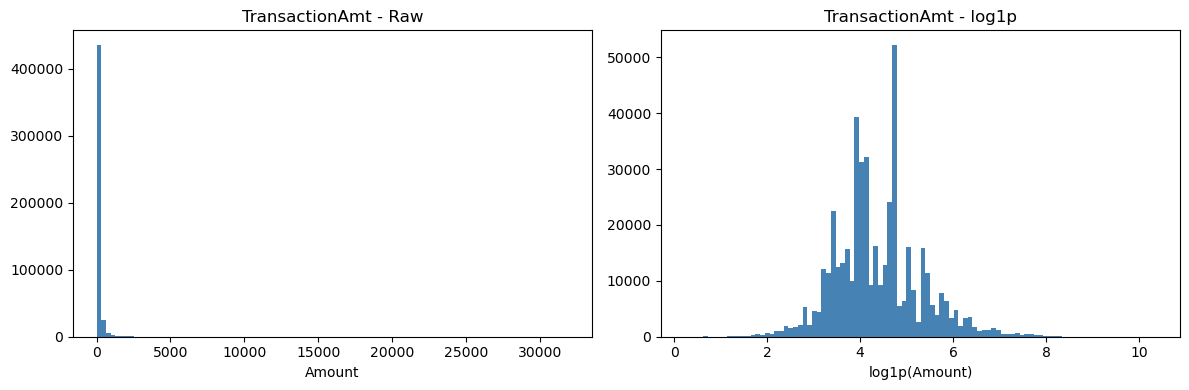

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['TransactionAmt'], bins=100, color='steelblue')
axes[0].set_title('TransactionAmt - Raw')
axes[0].set_xlabel('Amount')
axes[1].hist(np.log1p(X_train['TransactionAmt']), bins=100, color='steelblue')
axes[1].set_title('TransactionAmt - log1p')
axes[1].set_xlabel('log1p(Amount)')
plt.tight_layout()
plt.show()

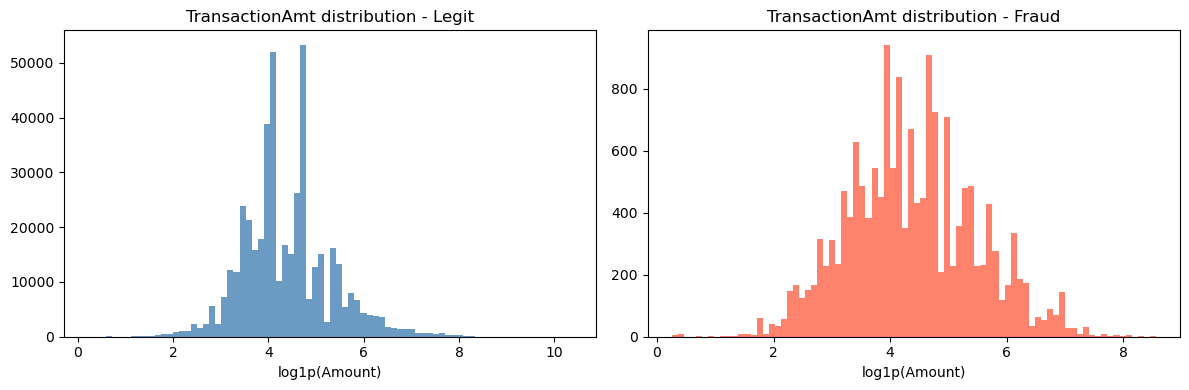

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label, color in zip(axes, [0, 1], ['steelblue', 'tomato']):
    vals = X_train.loc[y_train == label, 'TransactionAmt']
    ax.hist(np.log1p(vals), bins=80, color=color, alpha=0.8)
    ax.set_title(f'TransactionAmt distribution - {"Legit" if label == 0 else "Fraud"}')
    ax.set_xlabel('log1p(Amount)')
plt.tight_layout()
plt.show()

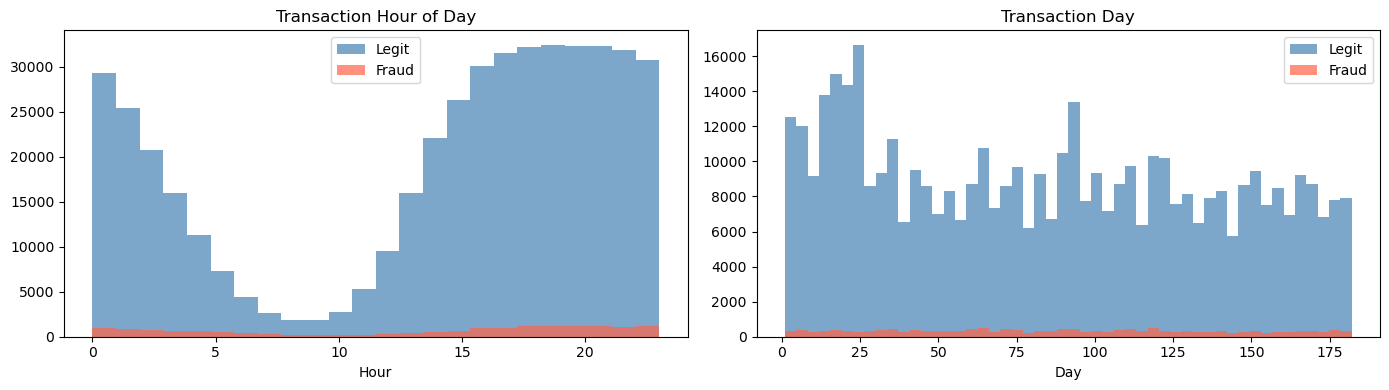

In [47]:
hours = ((X_train['TransactionDT'] // 3600) % 24).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(hours[y_train == 0], bins=24, color='steelblue', alpha=0.7, label='Legit')
axes[0].hist(hours[y_train == 1], bins=24, color='tomato',    alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].legend()

days = (X_train['TransactionDT'] // 86400).astype(int)
axes[1].hist(days[y_train == 0], bins=50, color='steelblue', alpha=0.7, label='Legit')
axes[1].hist(days[y_train == 1], bins=50, color='tomato',    alpha=0.7, label='Fraud')
axes[1].set_title('Transaction Day')
axes[1].set_xlabel('Day')
axes[1].legend()

plt.tight_layout()
plt.show()

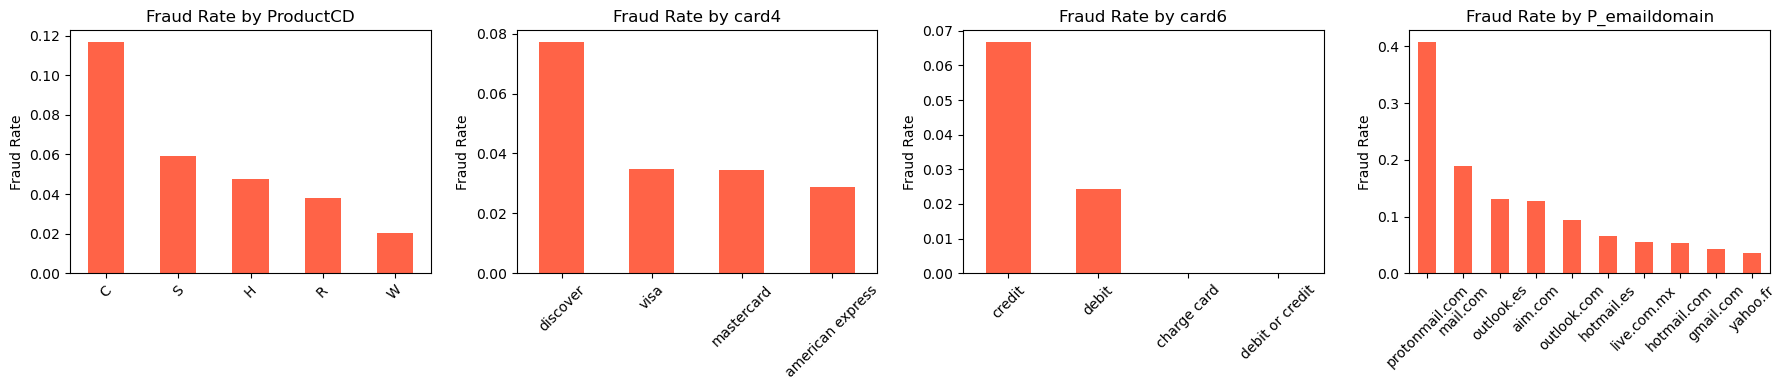

In [48]:
top_cats = ['ProductCD', 'card4', 'card6', 'P_emaildomain']
fig, axes = plt.subplots(1, len(top_cats), figsize=(18, 4))

for ax, col in zip(axes, top_cats):
    fraud_rate_by_cat = train.groupby(col)[TARGET].mean().sort_values(ascending=False).head(10)
    fraud_rate_by_cat.plot(kind='bar', ax=ax, color='tomato')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Data Cleaning

### Missing Value Analysis

       Missing Count  Missing %
id_24         468639      99.20
id_25         468330      99.13
id_07         468318      99.13
id_08         468318      99.13
id_21         468313      99.13
id_26         468310      99.13
id_27         468306      99.13
id_23         468306      99.13
id_22         468306      99.13
dist2         442276      93.62
D7            441253      93.40
id_18         436308      92.35
D13           422692      89.47
D14           422488      89.43
D12           420479      89.00
id_03         419240      88.74
id_04         419240      88.74
D6            413676      87.56
id_33         413642      87.56
id_10         412303      87.27
id_09         412303      87.27
D8            412303      87.27
D9            412303      87.27
id_30         410249      86.84
id_32         410229      86.83
id_34         410062      86.80
id_14         408264      86.42
V155          406761      86.10
V138          406761      86.10
V156          406761      86.10


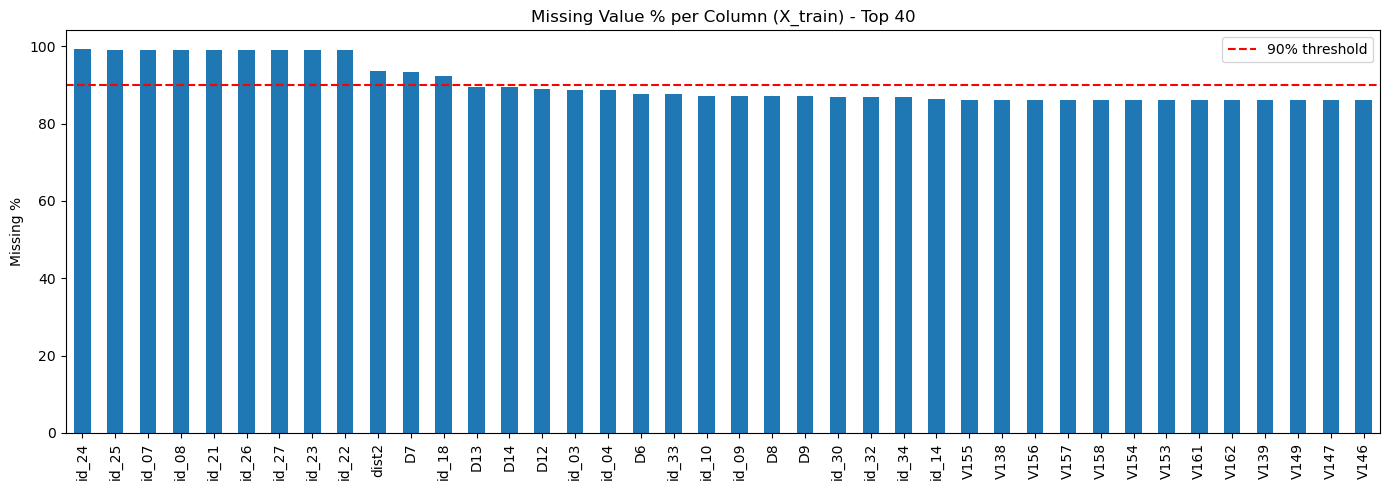

In [22]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(X_train) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df.head(30))

plt.figure(figsize=(14, 5))
missing_pct.head(40).plot(kind='bar')
plt.title('Missing Value % per Column (X_train) - Top 40')
plt.ylabel('Missing %')
plt.axhline(y=90, color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### Drop High-Missing Columns (>90%)

In [23]:
with mlflow.start_run(run_name='DecisionTree_Cleaning'):
    missing_pct_local = (X_train.isnull().mean() * 100)
    high_missing = missing_pct_local[missing_pct_local > 90].index.tolist()
    print(f'Dropping {len(high_missing)} columns with >90% missing: {high_missing}')

    X_train_c = X_train.drop(columns=high_missing)
    X_val_c   = X_val.drop(columns=[c for c in high_missing if c in X_val.columns])
    X_test_c  = X_test_raw.drop(columns=[c for c in high_missing if c in X_test_raw.columns])

    remaining_missing = X_train_c.isnull().sum().sum()

    mlflow.log_metric('original_feature_count', X_train.shape[1])
    mlflow.log_metric('dropped_high_missing_cols', len(high_missing))
    mlflow.log_metric('remaining_feature_count', X_train_c.shape[1])
    mlflow.log_metric('remaining_missing_values', int(remaining_missing))

    print(f'Features after drop: {X_train_c.shape[1]}')
    print(f'Remaining na cells: {remaining_missing}')

Dropping 12 columns with >90% missing: ['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']
Features after drop: 420
Remaining na cells: 86849187
🏃 View run DecisionTree_Cleaning at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/361466278bc84e61a710fa73ac96d36c
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


### Imputation

In [ ]:
def impute(df_train, df_val, df_test):
    df_train, df_val, df_test = df_train.copy(), df_val.copy(), df_test.copy()

    common_cols = sorted(set(df_train.columns) & set(df_val.columns) & set(df_test.columns))
    df_train = df_train[common_cols]
    df_val = df_val[common_cols]
    df_test = df_test[common_cols]

    for col in common_cols:
        if df_train[col].isnull().any() or df_val[col].isnull().any() or df_test[col].isnull().any():
            if df_train[col].dtype == 'object':
                mode_vals = df_train[col].mode(dropna=True)
                fill_val = mode_vals.iloc[0] if len(mode_vals) else 'Unknown'
            else:
                fill_val = df_train[col].median()

            df_train[col] = df_train[col].fillna(fill_val)
            df_val[col] = df_val[col].fillna(fill_val)
            df_test[col] = df_test[col].fillna(fill_val)

    return df_train, df_val, df_test

X_train_c, X_val_c, X_test_c = impute(X_train_c, X_val_c, X_test_c)

print('Nulls in X_train:', X_train_c.isnull().sum().sum())
print('Nulls in X_val:', X_val_c.isnull().sum().sum())
print('Nulls in X_test:', X_test_c.isnull().sum().sum())
print('Aligned feature count:', X_train_c.shape[1])

Nulls in X_train: 0
Nulls in X_val: 0
Nulls in X_test: 0
Aligned feature count: 392


## Feature Engineering

In [26]:
def add_features(df):
    df = df.copy()

    if 'TransactionAmt' in df.columns:
        df['TransactionAmt_log1p'] = np.log1p(df['TransactionAmt'])
        df['TransactionAmt_cents'] = (df['TransactionAmt'] % 1).round(2)

    if 'TransactionDT' in df.columns:
        df['TransactionDT_day']  = (df['TransactionDT'] // 86400).astype('float32')
        df['TransactionDT_hour'] = ((df['TransactionDT'] // 3600) % 24).astype('float32')

    for col in ['P_emaildomain', 'R_emaildomain']:
        if col in df.columns:
            df[f'{col}_provider'] = df[col].astype(str).str.split('.').str[0]

    for col in ['card1', 'card2', 'card3', 'card5']:
        if col in df.columns and 'TransactionAmt' in df.columns:
            grp = df.groupby(col)['TransactionAmt']
            df[f'{col}_amt_mean'] = df[col].map(grp.mean())
            df[f'{col}_amt_std']  = df[col].map(grp.std().fillna(0))

    return df

with mlflow.start_run(run_name='DecisionTree_Feature_Engineering'):
    X_train_fe = add_features(X_train_c)
    X_val_fe   = add_features(X_val_c)
    X_test_fe  = add_features(X_test_c)

    new_cols = [c for c in X_train_fe.columns if c not in X_train_c.columns]
    mlflow.log_metric('engineered_feature_count', len(new_cols))
    print(f'New features added ({len(new_cols)}): {new_cols}')
    print('X_train_fe shape:', X_train_fe.shape)

New features added (14): ['TransactionAmt_log1p', 'TransactionAmt_cents', 'TransactionDT_day', 'TransactionDT_hour', 'P_emaildomain_provider', 'R_emaildomain_provider', 'card1_amt_mean', 'card1_amt_std', 'card2_amt_mean', 'card2_amt_std', 'card3_amt_mean', 'card3_amt_std', 'card5_amt_mean', 'card5_amt_std']
X_train_fe shape: (472432, 406)
🏃 View run DecisionTree_Feature_Engineering at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/8096ef0dcf4744d2bbe1be18d288fb35
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


### Approach 1 - Label Encoding

In [29]:
cat_cols = X_train_fe.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    all_vals = pd.concat([X_train_fe[col], X_val_fe[col], X_test_fe[col]]).astype(str).unique()
    le.fit(all_vals)
    X_train_fe[col] = le.transform(X_train_fe[col].astype(str))
    X_val_fe[col]   = le.transform(X_val_fe[col].astype(str))
    X_test_fe[col]  = le.transform(X_test_fe[col].astype(str))

Categorical columns: []


### Approach 2 - OHE + WOE Encoding

In [30]:
import numpy as np


LOW_CARD_COLS  = ['ProductCD', 'card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
HIGH_CARD_COLS = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo']

def woe_encode(train_col, val_col, test_col, y_train):
    woe_map = {}
    total_ev  = y_train.sum()
    total_nev = (1 - y_train).sum()
    for cat in train_col.astype(str).unique():
        mask      = train_col.astype(str) == cat
        events    = y_train[mask].sum()
        non_events = (1 - y_train[mask]).sum()
        dist_ev   = (events    + 0.5) / (total_ev  + 0.5)
        dist_nev  = (non_events + 0.5) / (total_nev + 0.5)
        woe_map[cat] = np.log(dist_ev / dist_nev)
    return (train_col.astype(str).map(woe_map).fillna(0),
            val_col.astype(str).map(woe_map).fillna(0),
            test_col.astype(str).map(woe_map).fillna(0))

X_train_fe2 = X_train_c.copy()
X_val_fe2   = X_val_c.copy()
X_test_fe2  = X_test_c.copy()

from numpy import log1p
for df in [X_train_fe2, X_val_fe2, X_test_fe2]:
    if 'TransactionAmt' in df.columns:
        df['TransactionAmt_log1p'] = log1p(df['TransactionAmt'])
        df['TransactionAmt_cents'] = (df['TransactionAmt'] % 1).round(2)
    if 'TransactionDT' in df.columns:
        df['TransactionDT_day']  = (df['TransactionDT'] // 86400).astype('float32')
        df['TransactionDT_hour'] = ((df['TransactionDT'] // 3600) % 24).astype('float32')

ohe_cols_present = [c for c in LOW_CARD_COLS if c in X_train_fe2.columns]
X_train_fe2 = pd.get_dummies(X_train_fe2, columns=ohe_cols_present, drop_first=True)
X_val_fe2   = pd.get_dummies(X_val_fe2,   columns=ohe_cols_present, drop_first=True)
X_test_fe2  = pd.get_dummies(X_test_fe2,  columns=ohe_cols_present, drop_first=True)

X_val_fe2   = X_val_fe2.reindex(columns=X_train_fe2.columns, fill_value=0)
X_test_fe2  = X_test_fe2.reindex(columns=X_train_fe2.columns, fill_value=0)

for col in HIGH_CARD_COLS:
    if col in X_train_fe2.columns:
        X_train_fe2[col], X_val_fe2[col], X_test_fe2[col] = woe_encode(
            X_train_fe2[col], X_val_fe2[col], X_test_fe2[col], y_train
        )

remaining_cats = X_train_fe2.select_dtypes(include='object').columns.tolist()
le2 = LabelEncoder()
for col in remaining_cats:
    all_vals = pd.concat([X_train_fe2[col], X_val_fe2[col], X_test_fe2[col]]).astype(str).unique()
    le2.fit(all_vals)
    X_train_fe2[col] = le2.transform(X_train_fe2[col].astype(str))
    X_val_fe2[col]   = le2.transform(X_val_fe2[col].astype(str))
    X_test_fe2[col]  = le2.transform(X_test_fe2[col].astype(str))

print('Approach 2 encoding done.')
print('X_train_fe2 shape:', X_train_fe2.shape)

Approach 2 encoding done.
X_train_fe2 shape: (472432, 404)


## Feature Selection

### Feature Selection - Approach 1 (Label Encoding)
#### Correlation Filter

In [31]:
corr_matrix = X_train_fe.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.90)]

print(f'Columns with correlation > 0.90: {len(high_corr_cols)}')
print(high_corr_cols)

X_train_corr = X_train_fe.drop(columns=high_corr_cols)
X_val_corr   = X_val_fe.drop(columns=[c for c in high_corr_cols if c in X_val_fe.columns])
X_test_corr  = X_test_fe.drop(columns=[c for c in high_corr_cols if c in X_test_fe.columns])

print(f'Approach 1 - dropped {len(high_corr_cols)} correlated cols, shape: {X_train_corr.shape}')

Columns with correlation > 0.90: 179
['C10', 'C11', 'C12', 'C14', 'C2', 'C4', 'C6', 'C7', 'C8', 'C9', 'D2', 'V102', 'V103', 'V105', 'V106', 'V11', 'V113', 'V126', 'V127', 'V128', 'V13', 'V132', 'V133', 'V134', 'V137', 'V140', 'V143', 'V145', 'V147', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V16', 'V160', 'V163', 'V164', 'V167', 'V168', 'V177', 'V178', 'V179', 'V18', 'V182', 'V183', 'V190', 'V192', 'V193', 'V196', 'V197', 'V198', 'V199', 'V20', 'V201', 'V202', 'V203', 'V204', 'V207', 'V21', 'V211', 'V212', 'V213', 'V218', 'V219', 'V22', 'V222', 'V225', 'V231', 'V232', 'V233', 'V236', 'V237', 'V239', 'V243', 'V244', 'V249', 'V251', 'V253', 'V254', 'V256', 'V257', 'V259', 'V265', 'V266', 'V269', 'V271', 'V272', 'V273', 'V274', 'V275', 'V278', 'V279', 'V28', 'V280', 'V292', 'V293', 'V294', 'V295', 'V296', 'V297', 'V298', 'V299', 'V30', 'V301', 'V304', 'V306', 'V307', 'V308', 'V309', 'V31', 'V311', 'V315', 'V316', 'V317', 'V318', 'V32', 'V321',

### Correlation Heatmap

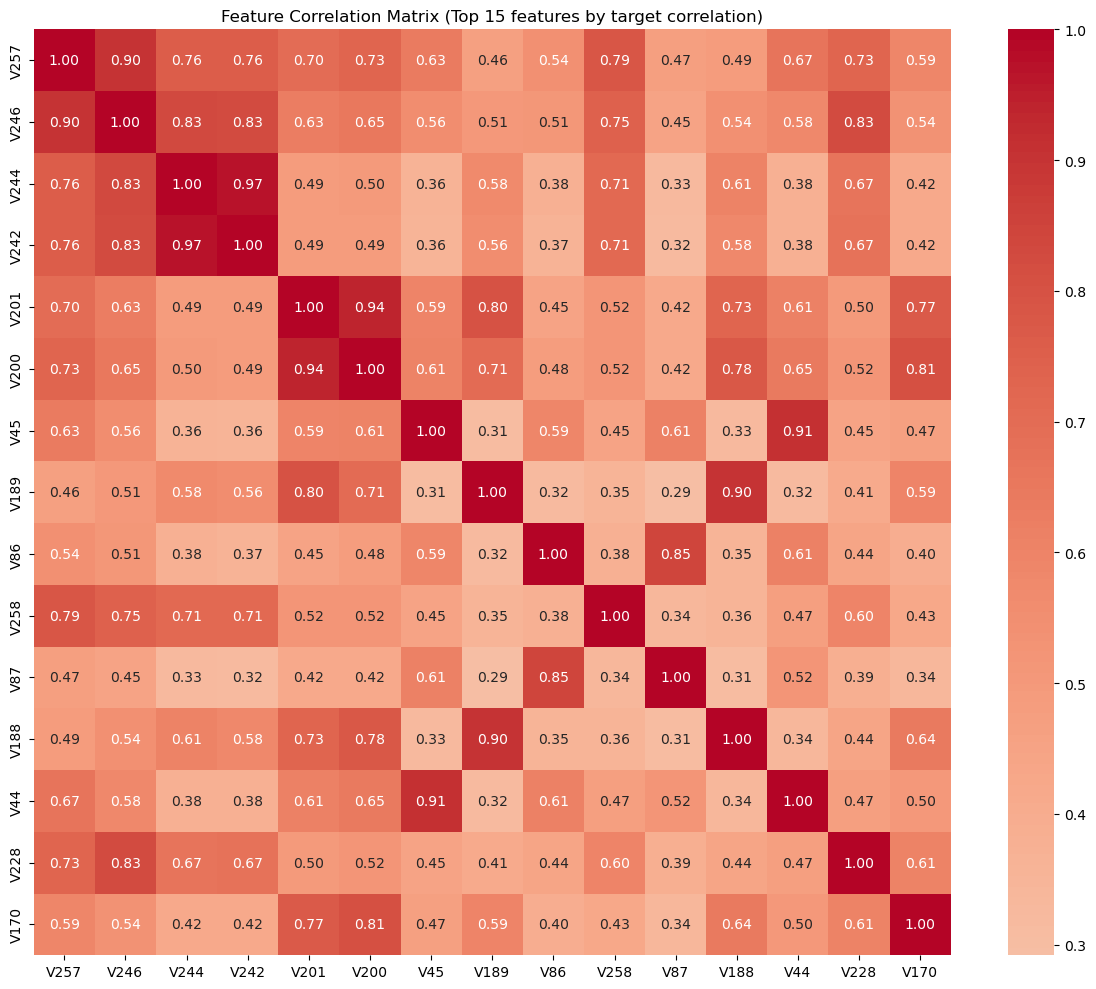

In [32]:
corr_with_target = X_train_fe.corrwith(y_train).abs().sort_values(ascending=False)
top_features = corr_with_target.head(15).index.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(
    X_train_fe[top_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Feature Correlation Matrix (Top 15 features by target correlation)')
plt.tight_layout()
plt.show()

### Information Value (IV)

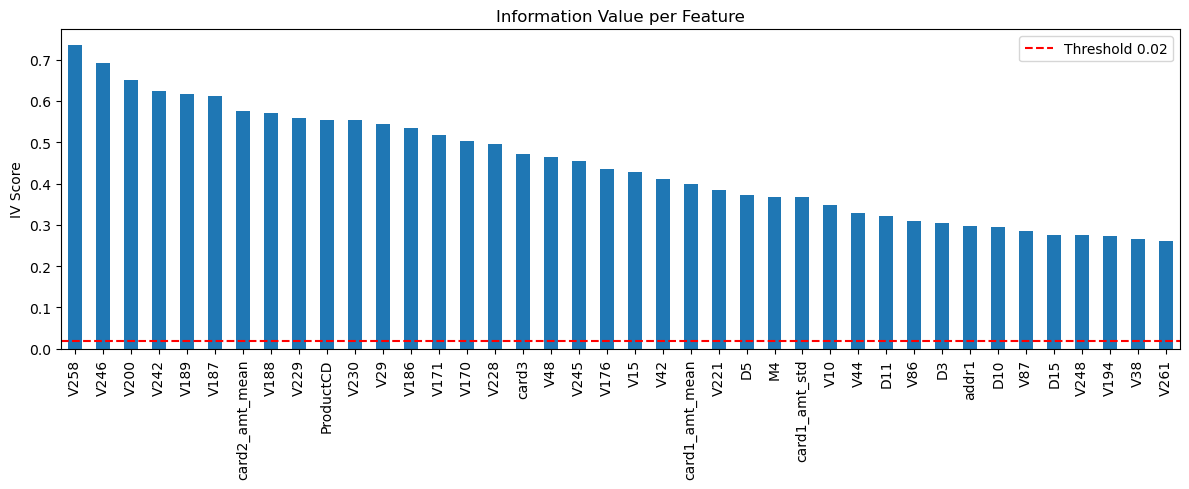

Weak features (IV < 0.02): 98
Shape after IV filter: (472432, 129)


In [33]:
def calculate_iv(X, y):
    iv_scores = {}
    total_ev  = y.sum()
    total_nev = (1 - y).sum()
    for col in X.columns:
        if X[col].nunique() > 10:
            try:
                bins = pd.qcut(X[col], q=10, duplicates='drop')
            except Exception:
                bins = X[col]
        else:
            bins = X[col]
        iv = 0
        for val in bins.unique():
            mask       = bins == val
            events     = y[mask].sum()
            non_events = (1 - y[mask]).sum()
            dist_ev    = (events    + 0.5) / (total_ev  + 0.5)
            dist_nev   = (non_events + 0.5) / (total_nev + 0.5)
            iv         += (dist_ev - dist_nev) * np.log(dist_ev / dist_nev)
        iv_scores[col] = iv
    return pd.Series(iv_scores).sort_values(ascending=False)

iv_scores = calculate_iv(X_train_corr, y_train)

plt.figure(figsize=(12, 5))
iv_scores.head(40).plot(kind='bar')
plt.axhline(y=0.02, color='red', linestyle='--', label='Threshold 0.02')
plt.title('Information Value per Feature')
plt.ylabel('IV Score')
plt.legend()
plt.tight_layout()
plt.show()

weak_features = iv_scores[iv_scores < 0.02].index.tolist()
print(f'Weak features (IV < 0.02): {len(weak_features)}')

X_train_iv = X_train_corr.drop(columns=weak_features)
X_val_iv   = X_val_corr.drop(columns=[c for c in weak_features if c in X_val_corr.columns])
X_test_iv  = X_test_corr.drop(columns=[c for c in weak_features if c in X_test_corr.columns])

print(f'Approach 1 - weak IV features: {len(weak_features)}')
print(f'Approach 1 - shape after IV filter: {X_train_iv.shape}')

### RFE

In [34]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier as _DT

rfe = RFE(estimator=_DT(max_depth=5, random_state=42), n_features_to_select=50)
rfe.fit(X_train_iv, y_train)

selected_rfe = X_train_iv.columns[rfe.support_].tolist()

X_train_sel = X_train_iv[selected_rfe]
X_val_sel   = X_val_iv[selected_rfe]
X_test_sel  = X_test_iv[selected_rfe]

print(f'Approach 1 - RFE selected {len(selected_rfe)} features')
print(selected_rfe)

RFE selected 50 features
['C1', 'C13', 'C5', 'D1', 'D10', 'D11', 'D12', 'D14', 'D15', 'D3', 'D4', 'D5', 'D6', 'D9', 'DeviceInfo', 'DeviceType', 'M4', 'M6', 'M8', 'P_emaildomain', 'ProductCD', 'TransactionAmt', 'TransactionDT', 'V130', 'V148', 'V174', 'V189', 'V195', 'V246', 'V247', 'V248', 'V250', 'V252', 'V255', 'V258', 'V260', 'V261', 'V262', 'V282', 'V283', 'V289', 'V44', 'V48', 'V53', 'V55', 'V56', 'V62', 'card1', 'card2', 'card3']


In [35]:
with mlflow.start_run(run_name='DecisionTree_Feature_Selection'):
    mlflow.log_metric('pre_corr_filter_features',  X_train_fe.shape[1])
    mlflow.log_metric('post_corr_filter_features', X_train_corr.shape[1])
    mlflow.log_metric('dropped_correlated_cols',   len(high_corr_cols))
    mlflow.log_metric('weak_iv_features_dropped',  len(weak_features))
    mlflow.log_metric('post_iv_filter_features',   X_train_iv.shape[1])
    mlflow.log_metric('rfe_selected_features',     len(selected_rfe))

🏃 View run DecisionTree_Feature_Selection at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/16431ad4e04f4a9f9e04e87dc4d7329c
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


### Feature Selection - Approach 2 (OHE + WOE)

In [39]:
corr_matrix2 = X_train_fe2.corr().abs()
upper2 = corr_matrix2.where(np.triu(np.ones(corr_matrix2.shape), k=1).astype(bool))
high_corr_cols2 = [col for col in upper2.columns if any(upper2[col] > 0.90)]

X_train_corr2 = X_train_fe2.drop(columns=high_corr_cols2)
X_val_corr2   = X_val_fe2.drop(columns=[c for c in high_corr_cols2 if c in X_val_fe2.columns])
X_test_corr2  = X_test_fe2.drop(columns=[c for c in high_corr_cols2 if c in X_test_fe2.columns])

print(f'Approach 2 - dropped {len(high_corr_cols2)} correlated cols, shape: {X_train_corr2.shape}')

Approach 2 - dropped 175 correlated cols, shape: (472432, 229)


In [41]:
iv_scores2 = calculate_iv(X_train_corr2, y_train)

weak_features2 = iv_scores2[iv_scores2 < 0.02].index.tolist()
print(f'Approach 2 - weak IV features: {len(weak_features2)}')

X_train_iv2 = X_train_corr2.drop(columns=weak_features2)
X_val_iv2   = X_val_corr2.drop(columns=[c for c in weak_features2 if c in X_val_corr2.columns])
X_test_iv2  = X_test_corr2.drop(columns=[c for c in weak_features2 if c in X_test_corr2.columns])

print(f'Shape after IV filter: {X_train_iv2.shape}')

Approach 2 - weak IV features: 104
Shape after IV filter: (472432, 125)


In [42]:
rfe2 = RFE(estimator=_DT(max_depth=5, random_state=42), n_features_to_select=min(50, X_train_iv2.shape[1]))
rfe2.fit(X_train_iv2, y_train)

selected_rfe2 = X_train_iv2.columns[rfe2.support_].tolist()

X_train_sel2 = X_train_iv2[selected_rfe2]
X_val_sel2   = X_val_iv2[selected_rfe2]
X_test_sel2  = X_test_iv2[selected_rfe2]

print(f'Approach 2 - RFE selected {len(selected_rfe2)} features')

Approach 2 - RFE selected 50 features


## Model Training - Decision Tree

In [38]:
from sklearn.model_selection import cross_validate, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    cv = cross_validate(
        model, X_tr, y_tr,
        cv=kf,
        scoring='roc_auc',
        return_train_score=True
    )
    train_auc = cv['train_score'].mean()
    val_auc   = cv['test_score'].mean() 

    model.fit(X_tr, y_tr)
    test_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    return {'train_auc': train_auc, 'val_auc': val_auc, 'test_auc': test_auc}

In [43]:
param_grid_dt = [
    {'max_depth': 3,    'min_samples_split': 2,   'min_samples_leaf': 1,  'criterion': 'gini',    'class_weight': None},
    {'max_depth': 3,    'min_samples_split': 10,  'min_samples_leaf': 4,  'criterion': 'gini',    'class_weight': 'balanced'},

    {'max_depth': 5,    'min_samples_split': 2,   'min_samples_leaf': 1,  'criterion': 'gini',    'class_weight': None},
    {'max_depth': 5,    'min_samples_split': 20,  'min_samples_leaf': 10, 'criterion': 'entropy', 'class_weight': 'balanced'},

    {'max_depth': 8,    'min_samples_split': 10,  'min_samples_leaf': 5,  'criterion': 'gini',    'class_weight': None},
    {'max_depth': 8,    'min_samples_split': 50,  'min_samples_leaf': 20, 'criterion': 'entropy', 'class_weight': 'balanced'},

    {'max_depth': 10,   'min_samples_split': 2,   'min_samples_leaf': 1,  'criterion': 'gini',    'class_weight': None},
    {'max_depth': 10,   'min_samples_split': 100, 'min_samples_leaf': 50, 'criterion': 'entropy', 'class_weight': 'balanced'},

    {'max_depth': 15,   'min_samples_split': 2,   'min_samples_leaf': 1,  'criterion': 'gini',    'class_weight': None},
    {'max_depth': None, 'min_samples_split': 2,   'min_samples_leaf': 1,  'criterion': 'gini',    'class_weight': None},
    {'max_depth': None, 'min_samples_split': 50,  'min_samples_leaf': 20, 'criterion': 'entropy', 'class_weight': 'balanced'},
]

feature_sets = {
    'label_encoding':   (X_train_sel,  X_val_sel,  X_test_sel),
    'ohe_woe_encoding': (X_train_sel2, X_val_sel2, X_test_sel2),
}

best_val_auc  = 0
best_params   = None
best_fs_name  = None

for fs_name, (X_tr, X_te, _) in feature_sets.items():
    for params in param_grid_dt:
        d  = params['max_depth']
        s  = params['min_samples_split']
        l  = params['min_samples_leaf']
        cr = params['criterion']
        cw = str(params['class_weight'])
        run_name = f"DT_{fs_name}_depth{d}_split{s}_leaf{l}_{cr}"

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag('model_type',   'DecisionTree')
            mlflow.set_tag('feature_set',  fs_name)

            model   = DecisionTreeClassifier(**params, random_state=42)
            metrics = evaluate_model(model, X_tr, X_te, y_train, y_val)

            mlflow.log_param('feature_set', fs_name)
            mlflow.log_params(params)
            mlflow.log_metric('train_auc',   metrics['train_auc'])
            mlflow.log_metric('val_auc',     metrics['val_auc'])
            mlflow.log_metric('test_auc',    metrics['test_auc'])
            mlflow.log_metric('overfit_gap', metrics['train_auc'] - metrics['val_auc'])

            mlflow.sklearn.log_model(model, name='model')

            if metrics['val_auc'] > best_val_auc:
                best_val_auc = metrics['val_auc']
                best_params  = params
                best_fs_name = fs_name

            print(f"{run_name[:60]:<60} | train={metrics['train_auc']:.4f} | val={metrics['val_auc']:.4f} | test={metrics['test_auc']:.4f}")

print(f'\nBest val AUC: {best_val_auc:.4f} | feature_set: {best_fs_name} | params: {best_params}')

2026/04/28 18:29:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_label_encoding_depth3_split2_leaf1_gini                   | train=0.6792 | val=0.6792 | test=0.6742
🏃 View run DT_label_encoding_depth3_split2_leaf1_gini at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/d2df1fb11bb04507a8ca89b29d60f4ea
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


2026/04/28 18:30:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_label_encoding_depth3_split10_leaf4_gini                  | train=0.7671 | val=0.7668 | test=0.7703
🏃 View run DT_label_encoding_depth3_split10_leaf4_gini at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/10c2347341484bcbbe9fd33e6b424b9c
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


2026/04/28 18:30:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

DT_ohe_woe_encoding_depth15_split2_leaf1_gini                | train=0.8817 | val=0.8242 | test=0.8257
🏃 View run DT_ohe_woe_encoding_depth15_split2_leaf1_gini at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/cf906d0003954e0abe09a8f8b0be7db6
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


2026/04/28 18:43:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_ohe_woe_encoding_depthNone_split2_leaf1_gini              | train=1.0000 | val=0.7618 | test=0.7679
🏃 View run DT_ohe_woe_encoding_depthNone_split2_leaf1_gini at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/baf000e6e2784a7ab5548335d5ba279e
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


2026/04/28 18:44:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DT_ohe_woe_encoding_depthNone_split50_leaf20_entropy         | train=0.9810 | val=0.8415 | test=0.8453
🏃 View run DT_ohe_woe_encoding_depthNone_split50_leaf20_entropy at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/f3039a124d564bdb8ab79e52cb7c50c0
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0

Best val AUC: 0.8654 | feature_set: ohe_woe_encoding | params: {'max_depth': 10, 'min_samples_split': 100, 'min_samples_leaf': 50, 'criterion': 'entropy', 'class_weight': 'balanced'}
